In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import Counter
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
def load_signals_from_folder(folder_path, label_path):
    signal_files = sorted(glob(os.path.join(folder_path, "signal_*.npy")))
    if not signal_files:
        raise FileNotFoundError("No signal_*.npy files found in folder.")
    
    print(f"📁 Found {len(signal_files)} signal files.")
    X = np.array([np.load(f) for f in signal_files])
    y = np.load(label_path)
    return X, y


In [3]:
def augment_each_class(X, y, target_per_class=1000):
    X_aug, y_aug = [], []
    for label in np.unique(y):
        class_signals = X[y == label]
        current_count = len(class_signals)
        needed = target_per_class - current_count
        augmented = []

        while len(augmented) < needed:
            for sig in class_signals:
                aug_sig = sig.copy()
                if random.random() < 0.5:
                    aug_sig = aug_sig[::-1]
                augmented.append(aug_sig)
                if len(augmented) >= needed:
                    break

        all_signals = np.concatenate([class_signals, np.array(augmented)])
        labels = np.full(target_per_class, label)
        X_aug.append(all_signals)
        y_aug.append(labels)

    return np.concatenate(X_aug), np.concatenate(y_aug)


In [4]:
folder_path = r"C:\Users\faizan\ECG_detection\cleaned_signals"
label_path = os.path.join(folder_path, "labels.npy")
X_raw, y_raw = load_signals_from_folder(folder_path, label_path)
X, y = augment_each_class(X_raw, y_raw, target_per_class=1000)

print(f"🔁 After augmentation: {X.shape}")
print("📊 Class distribution:", Counter(y))

📁 Found 222 signal files.
🔁 After augmentation: (3000, 5000)
📊 Class distribution: Counter({np.int64(0): 1000, np.int64(1): 1000, np.int64(2): 1000})


In [28]:
import os
import numpy as np

# Make sure this matches your augmented data
folder_to_save = r"C:\Users\faizan\ECG_detection\augmented_signals"
os.makedirs(folder_to_save, exist_ok=True)

# Save signals
for i, signal in enumerate(X):
    np.save(os.path.join(folder_to_save, f"signal_{i}.npy"), signal)

# Save labels
np.save(os.path.join(folder_to_save, "labels.npy"), y)

print(f"✅ Saved {len(X)} signals and labels to {folder_to_save}")


✅ Saved 3000 signals and labels to C:\Users\faizan\ECG_detection\augmented_signals


In [5]:
# ---------------------- Preprocessing ----------------------


X = (X - np.mean(X, axis=1, keepdims=True)) / (np.std(X, axis=1, keepdims=True) + 1e-8)
X = X[:, :1500]  # Downsample
X = X.reshape((X.shape[0], X.shape[1], 1))

In [6]:

# ---------------------- Train/Test Split ----------------------
num_classes = len(np.unique(y))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)


In [7]:
# ---------------------- Model ----------------------
def build_cnn_lstm_model(input_shape, num_classes):
    model = Sequential([
        Conv1D(64, 5, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Dropout(0.3),
        Conv1D(128, 5, activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_cnn_lstm_model(input_shape=(1500, 1), num_classes=num_classes)

C:\Users\faizan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# ---------------------- Training ----------------------
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 276ms/step - accuracy: 0.3666 - loss: 1.1006 - val_accuracy: 0.3625 - val_loss: 1.0988
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 246ms/step - accuracy: 0.3604 - loss: 1.0911 - val_accuracy: 0.3417 - val_loss: 1.0973
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 243ms/step - accuracy: 0.3700 - loss: 1.0873 - val_accuracy: 0.3458 - val_loss: 1.0912
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - accuracy: 0.3764 - loss: 1.0911 - val_accuracy: 0.4042 - val_loss: 1.0896
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 339ms/step - accuracy: 0.3918 - loss: 1.0870 - val_accuracy: 0.3750 - val_loss: 1.0828
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 0.3923 - loss: 1.0858 - val_accuracy: 0.4042 - val_loss: 1.0853
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - accuracy: 0.3886 - loss: 1.0871 - val_accuracy: 0.4125 - val_loss: 1.0836
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.4099 - loss: 1.0786 - 

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step

🧾 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       200
           1       0.98      0.93      0.95       200
           2       0.98      0.97      0.98       200

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600

✅ Accuracy: 96.17%


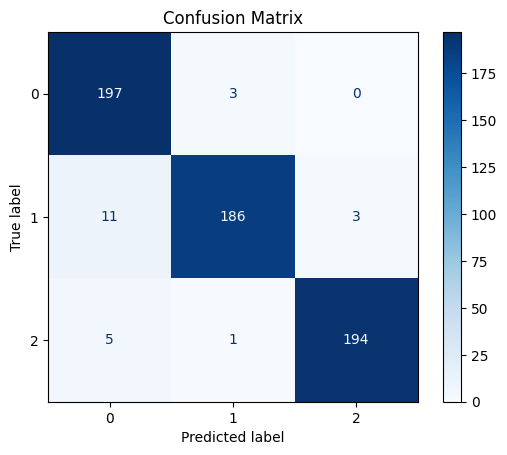

In [9]:
# ---------------------- Evaluation ----------------------
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

print("\n🧾 Classification Report:")
print(classification_report(y_test, y_pred_labels))
acc = accuracy_score(y_test, y_pred_labels)
print(f"✅ Accuracy: {acc * 100:.2f}%")

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


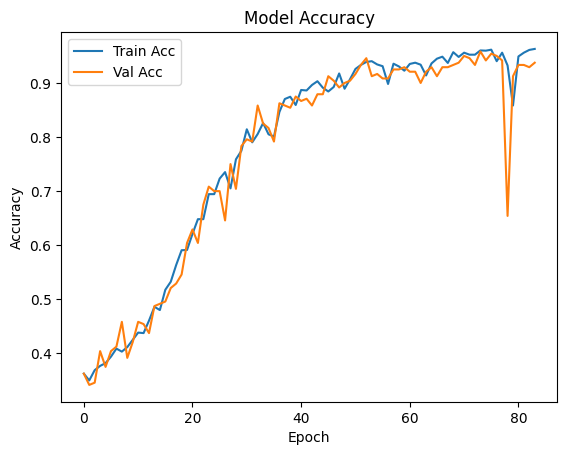

In [10]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

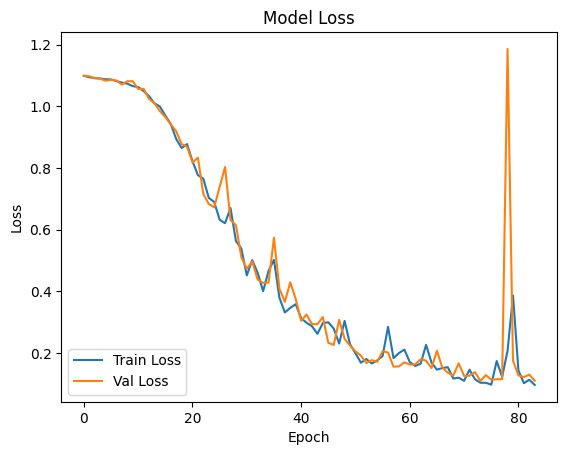

In [11]:



plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [48]:
model.save("cnn_lstm_cad_model.h5")  # or .keras


In [47]:
import numpy as np
from tensorflow.keras.models import load_model

# Step 1: Load the trained model
model = load_model(r"C:\Users\faizan\ECG_detection\models\cnn_lstm_cad_model.h5")  # Or .h5 if you saved it that way
print("✅ Model loaded.")

# Step 2: Define class labels
class_names = ["Normal", "Pre-CAD", "CAD"]

# Step 3: Preprocessing function
def preprocess_signal(signal):
    signal = signal[:1500]  # Downsample to 1500 points
    signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)  # Normalize
    return signal.reshape(1, 1500, 1)

# Step 4: Load test signal
signal_path = r"C:\Users\faizan\ECG_detection\augmented_signals\signal_202.npy"

signal = np.load(signal_path)
print(f"📂 Loaded: {signal_path}, Shape: {signal.shape}")

# Step 5: Preprocess and predict
preprocessed = preprocess_signal(signal)
prediction = model.predict(preprocessed)
predicted_class = np.argmax(prediction)
confidence = prediction[0][predicted_class] * 100

# Step 6: Output result
print(f"🧠 Predicted Class: {class_names[predicted_class]}")
print(f"📊 Confidence: {confidence:.2f}%")


✅ Model loaded.
📂 Loaded: C:\Users\faizan\ECG_detection\augmented_signals\signal_202.npy, Shape: (1500, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
🧠 Predicted Class: Normal
📊 Confidence: 99.87%
